# Librerias


In [1]:
# importing packages
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import json

In [2]:
pip install seaborn

In [3]:
pip install vapeplot

# Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import sys
sys.path.append('/content/drive/MyDrive/Results_Analysis/Notebooks')

In [6]:
from chargers import *
from metrics import *
from graphs import *

In [7]:
notebooks_route = "/content/drive/My Drive/Results_Analysis/Notebooks/"

In [8]:
experiment = "plebiscite" # presidential, plebiscite, or abortion
column_to_predict = 'constitucion_20_a'

In [9]:
results_route =  f"/content/drive/My Drive/Results_Analysis/results_dataframes/{experiment}/"
prompt_design_route =  f"/content/drive/My Drive/Results_Analysis/results_dataframes/{experiment}/Prompt Design Variations/"

# Dataframes Upload

In [10]:
d = {
    "apruebo" : 1,
    "rechazo" : 2,
    "nulo": 3,
    "approve":1,
    "reject": 2,
    "null":3,
    "approve/s":1,
    "reject/s": 2,
    "null/s":3
}

## Original Prompt Dataframes

In [11]:
gpt3_json_df = pd.read_csv(results_route + f"{experiment}_chile_chatgpt3_cot.csv")
gpt3_json = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_json_df, d, prompt_type='cot')
gpt4_json_df = pd.read_csv(results_route + f"{experiment}_chile_chatgpt4_cot.csv")
gpt4_json = data_charger(results_route +"exp_inputs_filtrado.csv", gpt4_json_df, d, prompt_type='cot')
llama_json = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_llama_cot.jsonl", d, prompt_type='cot')
mistral_json = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_mistral_cot.jsonl", d, prompt_type='cot')
t0_json = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_t0_cot.jsonl", d, prompt_type='cot', is_t0=True)

In [12]:
gpt3_text_with_preamble_df = pd.read_csv(results_route + f"{experiment}_chile_chatgpt3_text_with_preamble.csv")
gpt3_text_with_preamble = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_text_with_preamble_df, d)
llama_text_with_preamble = data_charger(results_route + "exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_llama_text_with_preamble.jsonl", d)
mistral_text_with_preamble = data_charger(results_route + "exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_mistral_text_with_preamble.jsonl", d)
t0_text_with_preamble = data_charger(results_route + "exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_t0_text_with_preamble.jsonl", d)

## Spanish Prompt Dataframes

In [13]:
gpt3_esp_df = pd.read_csv(results_route + f"{experiment}_chile_chatgpt3_text_with_preamble_spanish.csv")
gpt3_esp = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_esp_df, d, language='esp')
llama_esp = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +f"{experiment}_chile_llama_text_with_preamble_spanish.jsonl", d, language='esp')
mistral_esp = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +f"{experiment}_chile_mistral_text_with_preamble_spanish.jsonl", d, language='esp')

## Zero-shot Dataframes

In [14]:
gpt3_0_df = pd.read_csv(results_route + f"{experiment}_chile_chatgpt3_text_with_preamble_zeroshot.csv")
gpt3_0 = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_0_df, d)
llama_0 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_llama_text_with_preamble_zeroshot.jsonl", d)
mistral_0 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_mistral_text_with_preamble_zeroshot.jsonl", d)

## Prompt With Context Dataframes

In [15]:
gpt3_context_df = pd.read_csv(results_route + f"{experiment}_chile_chatgpt3_text_with_preamble_with_context.csv")
gpt3_context = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_context_df, d)
llama_context = data_charger(results_route + "exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_llama_text_with_preamble_with_context.jsonl", d)
mistral_context = data_charger(results_route + "exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_mistral_text_with_preamble_with_context.jsonl", d)

## Prompt Design Dataframes

In [16]:
gpt3_list_df = pd.read_csv(prompt_design_route + f"{experiment}_chile_chatgpt3_list.csv")
gpt3_list = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_list_df, d)
llama_list = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_llama_list.jsonl", d)
mistral_list = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_mistral_list.jsonl", d)
t0_list = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_t0_list.jsonl", d)

In [17]:
gpt3_text_df = pd.read_csv(prompt_design_route + f"{experiment}_chile_chatgpt3_text.csv")
gpt3_text = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_text_df, d)
llama_text = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_llama_text.jsonl", d)
mistral_text = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_mistral_text.jsonl", d)
t0_text = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_t0_text.jsonl", d)

In [18]:
gpt3_refpaper_df = pd.read_csv(prompt_design_route + f"{experiment}_chile_chatgpt3_refpaper.csv")
gpt3_refpaper = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_refpaper_df, d)
llama_refpaper = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_llama_refpaper.jsonl", d)
mistral_refpaper = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_mistral_refpaper.jsonl", d)
t0_refpaper = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_t0_refpaper.jsonl", d)

## Finetuning Dataframes

In [19]:
f_1 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +f"{experiment}_chile_f1_cot.jsonl", d, prompt_type='cot')
f_2 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +f"{experiment}_chile_f2_cot.jsonl", d, prompt_type='cot')
f_3 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +f"{experiment}_chile_f3_cot.jsonl", d, prompt_type='cot')
f_4 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +f"{experiment}_chile_f4_cot.jsonl", d, prompt_type='cot')
f_5 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +f"{experiment}_chile_f5_cot.jsonl", d, prompt_type='cot')
f_6 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +f"{experiment}_chile_f6_cot.jsonl", d, prompt_type='cot')
f_7 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +f"{experiment}_chile_f7_cot.jsonl", d, prompt_type='cot')
f_8 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +f"{experiment}_chile_f8_cot.jsonl", d, prompt_type='cot')

# Models and Prompt Analysis Metrics By Sociodemographic Groups

## Random Forest

In [20]:
# load dataset
df_rf = pd.read_csv(results_route + f"randomforest_{experiment}_chile.csv")
df_rf

,Unnamed: 0,sexo,edad,zona_u_r,gse,esc_nivel_1,info_enc_58,info_enc_30,religion_82,iden_pol_2,...,region_LIBERTADOR BERNARDO OHIGGINS,region_LOS LAGOS,region_LOS RÍOS,region_MAGALLANES,region_MAULE,region_METROPOLITANA,region_TARAPACÁ,region_VALPARAÍSO,region_ÑUBLE,pred
0,0,2,40,1,3,3,2,0.0,9,8,...,0,0,0,0,0,1,0,0,0,1.0
1,1,2,54,1,3,6,2,0.0,1,5,...,0,0,0,0,0,0,0,1,0,1.0
2,2,2,39,1,2,8,2,0.0,1,10,...,0,0,0,0,1,0,0,0,0,1.0
3,3,1,21,1,2,7,2,0.0,1,6,...,0,0,0,0,1,0,0,0,0,0.0
4,4,2,19,1,2,4,2,0.0,9,6,...,0,0,0,0,0,1,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,655,2,25,1,3,6,1,5.0,10,5,...,0,0,0,0,0,0,0,1,0,0.0
656,656,2,25,1,1,8,2,0.0,99,6,...,0,0,0,0,0,1,0,0,0,1.0
657,657,2,22,1,4,7,2,0.0,1,99,...,0,0,0,0,0,1,0,0,0,0.0
658,658,1,54,1,1,8,2,0.0,1,5,...,0,0,0,0,0,0,0,0,1,0.0


In [21]:
# Identificar las columnas de región
region_columns = [col for col in df_rf.columns if col.startswith('region_')]

# Reconstruir la columna original 'nom_region'
df_rf['nom_region'] = df_rf[region_columns].idxmax(axis=1).str.replace('region_', '')

results_rf = metrics_dataset_gen_chile(df_rf, column_to_predict)
results_rf

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.075940,0.914286,0.919147,0.924060
1,Man,0.083008,0.927273,0.922104,0.916992
2,Young adult,0.038763,0.974359,0.967753,0.961237
3,Adult,0.062678,0.930233,0.933764,0.937322
4,Senior adult,0.112491,0.876923,0.882184,0.887509
5,Metropolitan region,0.098401,0.902778,0.902188,0.901599
6,Other region,0.077212,0.932796,0.927765,0.922788
7,Indigenous people,0.000000,0.982759,0.991304,1.000000
8,Non-indigenous people,0.079091,0.913043,0.916959,0.920909
9,None (indigenous),0.000000,1.000000,1.000000,1.000000


## JSON

In [22]:
gpt3_json_metrics = metrics_dataset_gen_chile(gpt3_json, column_to_predict)
gpt3_json_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.221899,0.574026,0.660663,0.778101
1,Man,0.244051,0.581818,0.657551,0.755949
2,Young adult,0.099970,0.602564,0.721853,0.900030
3,Adult,0.251851,0.599483,0.665616,0.748149
4,Senior adult,0.244610,0.523077,0.618126,0.755390
5,Metropolitan region,0.266421,0.618056,0.670880,0.733579
6,Other region,0.207578,0.545699,0.646315,0.792422
7,Indigenous people,0.401197,0.517241,0.555042,0.598803
8,Non-indigenous people,0.215219,0.585284,0.670508,0.784781
9,None (indigenous),0.394511,0.250000,0.353885,0.605489


In [23]:
gpt4_json_metrics = metrics_dataset_gen_chile(gpt4_json, column_to_predict)
gpt4_json_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.088110,0.649351,0.758546,0.911890
1,Man,0.127314,0.687273,0.768960,0.872686
2,Young adult,0.096486,0.602564,0.722971,0.903514
3,Adult,0.126891,0.682171,0.765919,0.873109
4,Senior adult,0.036557,0.656410,0.780829,0.963443
5,Metropolitan region,0.067122,0.711806,0.807484,0.932878
6,Other region,0.113749,0.629032,0.735810,0.886251
7,Indigenous people,0.318590,0.586207,0.630233,0.681410
8,Non-indigenous people,0.081375,0.675585,0.778579,0.918625
9,None (indigenous),0.394511,0.250000,0.353885,0.605489


In [24]:
llama_json_metrics = metrics_dataset_gen_chile(llama_json, column_to_predict)
llama_json_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.046447,0.644156,0.768897,0.953553
1,Man,0.118171,0.650909,0.748974,0.881829
2,Young adult,0.107807,0.666667,0.763116,0.892193
3,Adult,0.087952,0.682171,0.780536,0.912048
4,Senior adult,0.059097,0.569231,0.709329,0.940903
5,Metropolitan region,0.125271,0.687500,0.769895,0.874729
6,Other region,0.044348,0.615591,0.748822,0.955652
7,Indigenous people,0.088418,0.620690,0.738524,0.911582
8,Non-indigenous people,0.075914,0.648829,0.762373,0.924086
9,None (indigenous),0.220896,0.750000,0.764275,0.779104


In [25]:
mistral_json_metrics = metrics_dataset_gen_chile(mistral_json, column_to_predict)
mistral_json_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.309292,0.454545,0.548277,0.690708
1,Man,0.349394,0.490909,0.559587,0.650606
2,Young adult,0.271549,0.500000,0.592983,0.728451
3,Adult,0.348031,0.472868,0.548160,0.651969
4,Senior adult,0.310478,0.451282,0.545525,0.689522
5,Metropolitan region,0.388859,0.461806,0.526081,0.611141
6,Other region,0.280278,0.475806,0.572882,0.719722
7,Indigenous people,0.430861,0.431034,0.490552,0.569139
8,Non-indigenous people,0.316312,0.471572,0.558157,0.683688
9,None (indigenous),0.394511,0.750000,0.670041,0.605489


In [26]:
t0_json_metrics = metrics_dataset_gen_chile(t0_json, column_to_predict)
t0_json_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entri

,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.989663,0.002597,0.004152,1.033709e-02
1,Man,1.000000,0.000000,NaN,0.000000e+00
2,Young adult,1.000000,0.000000,NaN,0.000000e+00
3,Adult,0.994219,0.002584,0.003571,5.780579e-03
4,Senior adult,0.990313,0.000000,0.000000,9.687303e-03
5,Metropolitan region,0.986897,0.003472,0.005490,1.310314e-02
6,Other region,1.000000,0.000000,0.000000,1.110223e-16
7,Indigenous people,1.000000,0.000000,NaN,0.000000e+00
8,Non-indigenous people,0.992888,0.001672,0.002708,7.112345e-03
9,None (indigenous),1.000000,0.000000,NaN,0.000000e+00


## Spanish

In [27]:
gpt3_esp_metrics = metrics_dataset_gen_chile(gpt3_esp, column_to_predict)
gpt3_esp_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.189937,0.574026,0.671918,0.810063
1,Man,0.226517,0.607273,0.680374,0.773483
2,Young adult,0.216862,0.589744,0.672819,0.783138
3,Adult,0.244905,0.617571,0.679444,0.755095
4,Senior adult,0.141715,0.528205,0.653954,0.858285
5,Metropolitan region,0.225567,0.618056,0.687464,0.774433
6,Other region,0.191711,0.564516,0.664759,0.808289
7,Indigenous people,0.346737,0.620690,0.636560,0.653263
8,Non-indigenous people,0.195067,0.585284,0.677757,0.804933
9,None (indigenous),0.000000,0.500000,0.666667,1.000000


In [28]:
mistral_esp_metrics = metrics_dataset_gen_chile(mistral_esp, column_to_predict)
mistral_esp_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.332780,0.449351,0.537029,0.667220
1,Man,0.328241,0.487273,0.564833,0.671759
2,Young adult,0.265386,0.461538,0.566905,0.734614
3,Adult,0.348510,0.498708,0.564952,0.651490
4,Senior adult,0.326988,0.400000,0.501774,0.673012
5,Metropolitan region,0.351344,0.479167,0.551176,0.648656
6,Other region,0.318111,0.454301,0.545301,0.681889
7,Indigenous people,0.408687,0.551724,0.570833,0.591313
8,Non-indigenous people,0.324970,0.456522,0.544678,0.675030
9,None (indigenous),0.394511,0.500000,0.547711,0.605489


In [29]:
llama_esp_metrics = metrics_dataset_gen_chile(llama_esp, column_to_predict)
llama_esp_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.290055,0.532468,0.608530,0.709945
1,Man,0.320156,0.516364,0.586933,0.679844
2,Young adult,0.138688,0.551282,0.672275,0.861312
3,Adult,0.307088,0.576227,0.629206,0.692912
4,Senior adult,0.346599,0.415385,0.507890,0.653401
5,Metropolitan region,0.315466,0.541667,0.604777,0.684534
6,Other region,0.293696,0.513441,0.594625,0.706304
7,Indigenous people,0.350916,0.620690,0.634569,0.649084
8,Non-indigenous people,0.297118,0.516722,0.595595,0.702882
9,None (indigenous),0.394511,0.500000,0.547711,0.605489


## Sin fewShot

In [30]:
print(gpt3_0[column_to_predict].value_counts())
print(gpt3_0["pred"].value_counts())

constitucion_20_a
2.0    350
1.0    292
3.0     18
Name: count, dtype: int64
pred
1    546
2     57
3     57
Name: count, dtype: int64


In [31]:
print(llama_0[column_to_predict].value_counts())
print(llama_0["pred"].value_counts())

constitucion_20_a
2.0    350
1.0    292
3.0     18
Name: count, dtype: int64
pred
1    312
3    260
2     88
Name: count, dtype: int64


In [32]:
print(mistral_0[column_to_predict].value_counts())
print(mistral_0["pred"].value_counts())

constitucion_20_a
2.0    350
1.0    292
3.0     18
Name: count, dtype: int64
pred
 1    453
 2    169
 3     31
-1      7
Name: count, dtype: int64


In [33]:
gpt_metrics_0 = metrics_dataset_gen_chile(gpt3_0, column_to_predict)
gpt_metrics_0

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.464993,0.446753,0.486913,0.535007
1,Man,0.388677,0.498182,0.548984,0.611323
2,Young adult,0.290008,0.589744,0.644305,0.709992
3,Adult,0.440259,0.462532,0.506515,0.559741
4,Senior adult,0.474535,0.430769,0.473428,0.525465
5,Metropolitan region,0.413473,0.510417,0.545831,0.586527
6,Other region,0.443226,0.435484,0.488716,0.556774
7,Indigenous people,0.437399,0.568966,0.565765,0.562601
8,Non-indigenous people,0.426369,0.458194,0.509455,0.573631
9,None (indigenous),0.627021,0.500000,0.427248,0.372979


In [34]:
llama_metrics_0 = metrics_dataset_gen_chile(llama_0, column_to_predict)
llama_metrics_0

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.478361,0.402597,0.454452,0.521639
1,Man,0.484432,0.407273,0.455066,0.515568
2,Young adult,0.450653,0.371795,0.443459,0.549347
3,Adult,0.486178,0.444444,0.476622,0.513822
4,Senior adult,0.489190,0.338462,0.407148,0.510810
5,Metropolitan region,0.460389,0.444444,0.487426,0.539611
6,Other region,0.498159,0.373656,0.428364,0.501841
7,Indigenous people,0.575839,0.379310,0.400484,0.424161
8,Non-indigenous people,0.472031,0.408027,0.460313,0.527969
9,None (indigenous),0.557923,0.250000,0.319384,0.442077


In [35]:
mistral_metrics_0 = metrics_dataset_gen_chile(mistral_0, column_to_predict)
mistral_metrics_0

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.205105,0.574026,0.666642,0.794895
1,Man,0.312239,0.527273,0.596918,0.687761
2,Young adult,0.253099,0.615385,0.674794,0.746901
3,Adult,0.250031,0.573643,0.650061,0.749969
4,Senior adult,0.269294,0.492308,0.588272,0.730706
5,Metropolitan region,0.309631,0.576389,0.628251,0.690369
6,Other region,0.211884,0.537634,0.639213,0.788116
7,Indigenous people,0.388719,0.500000,0.550069,0.611281
8,Non-indigenous people,0.242952,0.561873,0.645020,0.757048
9,None (indigenous),0.394511,0.250000,0.353885,0.605489


## With Context

In [36]:
llama_context_metrics = metrics_dataset_gen_chile(llama_context, column_to_predict)
llama_context_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.825819,0.067532,0.097329,0.174181
1,Man,0.809857,0.090909,0.123007,0.190143
2,Young adult,0.860284,0.051282,0.075026,0.139716
3,Adult,0.820676,0.082687,0.113185,0.179324
4,Senior adult,0.796047,0.076923,0.111713,0.203953
5,Metropolitan region,0.818427,0.079861,0.110931,0.181573
6,Other region,0.814331,0.075269,0.107114,0.185669
7,Indigenous people,0.805599,0.120690,0.148924,0.194401
8,Non-indigenous people,0.816625,0.073579,0.105019,0.183375
9,None (indigenous),1.000000,0.000000,NaN,0.000000


In [37]:
mistral_context_metrics = metrics_dataset_gen_chile(mistral_context, column_to_predict)
mistral_context_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.214637,0.566234,0.658035,0.785363
1,Man,0.260002,0.556364,0.635175,0.739998
2,Young adult,0.136000,0.615385,0.718802,0.864000
3,Adult,0.260286,0.591731,0.657499,0.739714
4,Senior adult,0.223822,0.482051,0.594737,0.776178
5,Metropolitan region,0.280642,0.590278,0.648457,0.719358
6,Other region,0.198186,0.540323,0.645595,0.801814
7,Indigenous people,0.318000,0.620690,0.649902,0.682000
8,Non-indigenous people,0.227226,0.556856,0.647284,0.772774
9,None (indigenous),0.394511,0.500000,0.547711,0.605489


In [38]:
gpt3_context_metrics = metrics_dataset_gen_chile(gpt3_context, column_to_predict)
gpt3_context_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.209568,0.594805,0.678805,0.790432
1,Man,0.209692,0.607273,0.686805,0.790308
2,Young adult,0.096802,0.615385,0.732017,0.903198
3,Adult,0.229036,0.617571,0.685795,0.770964
4,Senior adult,0.224471,0.558974,0.649681,0.775529
5,Metropolitan region,0.209226,0.642361,0.708883,0.790774
6,Other region,0.210898,0.567204,0.660001,0.789102
7,Indigenous people,0.380933,0.586207,0.602189,0.619067
8,Non-indigenous people,0.198417,0.602007,0.687606,0.801583
9,None (indigenous),0.000000,0.500000,0.666667,1.000000


## Prompting Designs

In [39]:
llama_text_metrics = metrics_dataset_gen_chile(llama_text, column_to_predict)
llama_list_metrics = metrics_dataset_gen_chile(llama_list, column_to_predict)
llama_text_with_preamble_metrics = metrics_dataset_gen_chile(llama_text_with_preamble, column_to_predict)
llama_refpaper_metrics = metrics_dataset_gen_chile(llama_refpaper, column_to_predict)

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/dri

In [40]:
mistral_text_metrics = metrics_dataset_gen_chile(mistral_text, column_to_predict)
mistral_list_metrics = metrics_dataset_gen_chile(mistral_list, column_to_predict)
mistral_text_with_preamble_metrics = metrics_dataset_gen_chile(mistral_text_with_preamble, column_to_predict)
mistral_refpaper_metrics = metrics_dataset_gen_chile(mistral_refpaper, column_to_predict)

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/dri

In [41]:
gpt3_text_metrics = metrics_dataset_gen_chile(gpt3_text, column_to_predict)
gpt3_list_metrics = metrics_dataset_gen_chile(gpt3_list, column_to_predict)
gpt3_text_with_preamble_metrics = metrics_dataset_gen_chile(gpt3_text_with_preamble, column_to_predict)
gpt3_refpaper_metrics = metrics_dataset_gen_chile(gpt3_refpaper, column_to_predict)

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/dri

In [42]:
t0_text_metrics = metrics_dataset_gen_chile(t0_text, column_to_predict)
t0_list_metrics = metrics_dataset_gen_chile(t0_list, column_to_predict)
t0_text_with_preamble_metrics = metrics_dataset_gen_chile(t0_text_with_preamble, column_to_predict)
t0_refpaper_metrics = metrics_dataset_gen_chile(t0_refpaper, column_to_predict)

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/dri

## Finetuning

In [43]:
f_1_metrics = metrics_dataset_gen_chile(f_1, column_to_predict)
f_1_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.243794,0.584416,0.659304,0.756206
1,Man,0.252414,0.621818,0.678927,0.747586
2,Young adult,0.249440,0.666667,0.706130,0.750560
3,Adult,0.268988,0.604651,0.661854,0.731012
4,Senior adult,0.222841,0.564103,0.653709,0.777159
5,Metropolitan region,0.277237,0.593750,0.651935,0.722763
6,Other region,0.230681,0.604839,0.677235,0.769319
7,Indigenous people,0.180415,0.586207,0.683524,0.819585
8,Non-indigenous people,0.254511,0.602007,0.666109,0.745489
9,None (indigenous),0.000000,0.500000,0.666667,1.000000


In [44]:
f_2_metrics = metrics_dataset_gen_chile(f_2, column_to_predict)
f_2_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.138853,0.631169,0.728437,0.861147
1,Man,0.189523,0.618182,0.701388,0.810477
2,Young adult,0.183224,0.564103,0.667322,0.816776
3,Adult,0.178347,0.651163,0.726540,0.821653
4,Senior adult,0.152465,0.600000,0.702603,0.847535
5,Metropolitan region,0.179725,0.652778,0.727004,0.820275
6,Other region,0.169807,0.604839,0.699821,0.830193
7,Indigenous people,0.169524,0.672414,0.743133,0.830476
8,Non-indigenous people,0.167807,0.622074,0.711954,0.832193
9,None (indigenous),0.000000,0.500000,0.666667,1.000000


In [45]:
f_3_metrics = metrics_dataset_gen_chile(f_3, column_to_predict)
f_3_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.154519,0.646753,0.732884,0.845481
1,Man,0.185120,0.607273,0.695923,0.814880
2,Young adult,0.211324,0.589744,0.674855,0.788676
3,Adult,0.175657,0.645995,0.724352,0.824343
4,Senior adult,0.111888,0.615385,0.727013,0.888112
5,Metropolitan region,0.163682,0.649306,0.731041,0.836318
6,Other region,0.150235,0.615591,0.713967,0.849765
7,Indigenous people,0.214740,0.655172,0.714342,0.785260
8,Non-indigenous people,0.160128,0.628763,0.719144,0.839872
9,None (indigenous),0.000000,0.500000,0.666667,1.000000


In [46]:
f_4_metrics = metrics_dataset_gen_chile(f_4, column_to_predict)
f_4_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.729788,0.202597,0.231570,0.270212
1,Man,0.686086,0.250909,0.278898,0.313914
2,Young adult,0.645851,0.307692,0.329290,0.354149
3,Adult,0.708158,0.235142,0.260442,0.291842
4,Senior adult,0.741261,0.164103,0.200830,0.258739
5,Metropolitan region,0.684443,0.232639,0.267827,0.315557
6,Other region,0.728843,0.215054,0.239868,0.271157
7,Indigenous people,0.701060,0.258621,0.277323,0.298940
8,Non-indigenous people,0.710257,0.220736,0.250575,0.289743
9,None (indigenous),0.809715,0.000000,0.000000,0.190285


In [47]:
f_5_metrics = metrics_dataset_gen_chile(f_5, column_to_predict)
f_5_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.266996,0.571429,0.642209,0.733004
1,Man,0.263378,0.600000,0.661329,0.736622
2,Young adult,0.311529,0.666667,0.677393,0.688471
3,Adult,0.300878,0.581395,0.634847,0.699122
4,Senior adult,0.197346,0.553846,0.655432,0.802654
5,Metropolitan region,0.262935,0.590278,0.655555,0.737065
6,Other region,0.260992,0.577957,0.648635,0.739008
7,Indigenous people,0.255656,0.655172,0.696917,0.744344
8,Non-indigenous people,0.273124,0.576923,0.643276,0.726876
9,None (indigenous),0.557923,0.500000,0.469258,0.442077


In [48]:
f_6_metrics = metrics_dataset_gen_chile(f_6, column_to_predict)
f_6_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.266155,0.579221,0.647429,0.733845
1,Man,0.269354,0.600000,0.658910,0.730646
2,Young adult,0.272202,0.641026,0.681661,0.727798
3,Adult,0.301847,0.583979,0.635983,0.698153
4,Senior adult,0.198594,0.574359,0.669147,0.801406
5,Metropolitan region,0.269075,0.590278,0.653115,0.730925
6,Other region,0.251234,0.586022,0.657472,0.748766
7,Indigenous people,0.291577,0.586207,0.641546,0.708423
8,Non-indigenous people,0.262659,0.586957,0.653610,0.737341
9,None (indigenous),0.220896,0.750000,0.764275,0.779104


In [49]:
f_7_metrics = metrics_dataset_gen_chile(f_7, column_to_predict)
f_7_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_j

,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.994104,0.002597,0.003606,5.896422e-03
1,Man,1.000000,0.000000,NaN,0.000000e+00
2,Young adult,1.000000,0.000000,NaN,0.000000e+00
3,Adult,0.994097,0.002584,0.003595,5.903458e-03
4,Senior adult,1.000000,0.000000,NaN,0.000000e+00
5,Metropolitan region,1.000000,0.000000,0.000000,1.110223e-16
6,Other region,0.993887,0.002688,0.003734,6.113041e-03
7,Indigenous people,1.000000,0.000000,NaN,0.000000e+00
8,Non-indigenous people,0.995910,0.001672,0.002374,4.089619e-03
9,None (indigenous),1.000000,0.000000,NaN,0.000000e+00


In [50]:
f_8_metrics = metrics_dataset_gen_chile(f_8, column_to_predict)
f_8_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is depreca

,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.990794,0.0,0.0,9.205763e-03
1,Man,1.000000,0.0,NaN,0.000000e+00
2,Young adult,1.000000,0.0,NaN,0.000000e+00
3,Adult,0.991525,0.0,0.0,8.475310e-03
4,Senior adult,1.000000,0.0,NaN,0.000000e+00
5,Metropolitan region,0.997179,0.0,0.0,2.820917e-03
6,Other region,0.994089,0.0,0.0,5.910695e-03
7,Indigenous people,1.000000,0.0,NaN,0.000000e+00
8,Non-indigenous people,0.993657,0.0,0.0,6.343420e-03
9,None (indigenous),1.000000,0.0,NaN,0.000000e+00


# Line Plots

## Performance comparison between models

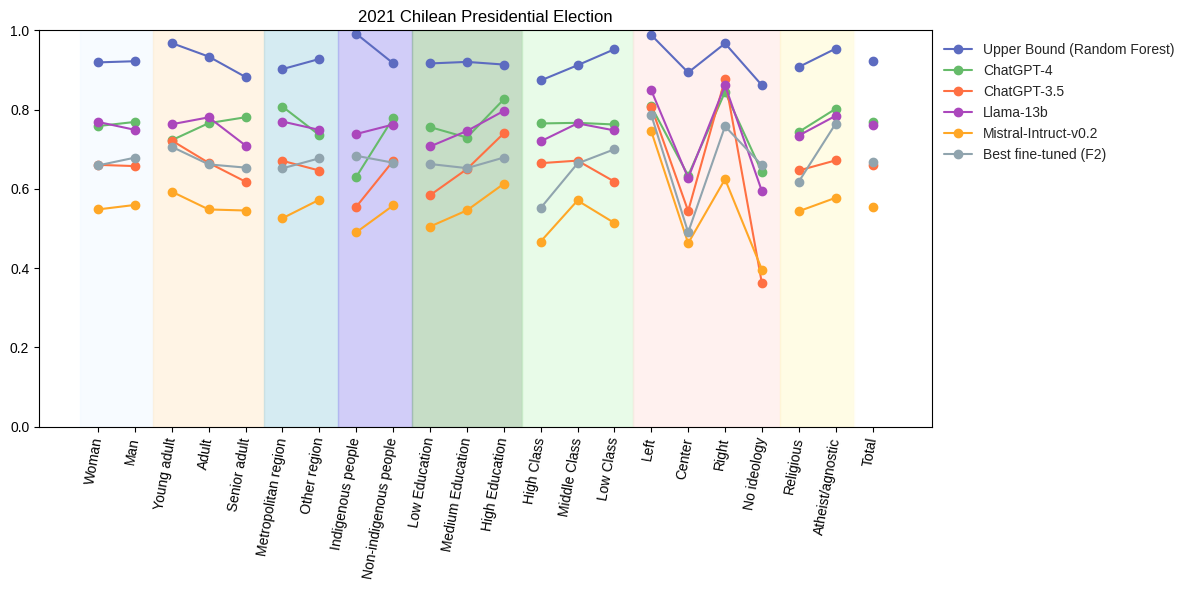

In [51]:
# Colors for each model
modelos_colores = {
    "Upper Bound (Random Forest)": "#5c6bc0",
    "ChatGPT-4": "#66bb6a",
    "ChatGPT-3.5": "#ff7043",
    "Llama-13b": "#ab47bc",
    "Mistral-Intruct-v0.2": "#ffa726",
    "T-zero": "#f48fb1",
    "Best fine-tuned (F2)": "#90a4ae",
    "Embedding + RandomForest": "#1e88e5"
}

modelos = [results_rf, gpt4_json_metrics, gpt3_json_metrics, llama_json_metrics, mistral_json_metrics, f_1_metrics]
modelos_nombres = ["Upper Bound (Random Forest)", "ChatGPT-4", "ChatGPT-3.5", "Llama-13b", "Mistral-Intruct-v0.2", "Best fine-tuned (F2)", "Embedding + RandomForest"]
sociodemographic_line_plot(modelos, modelos_colores, modelos_nombres, "2021 Chilean Presidential Election")

## Performance comparison between prompt variation for each model

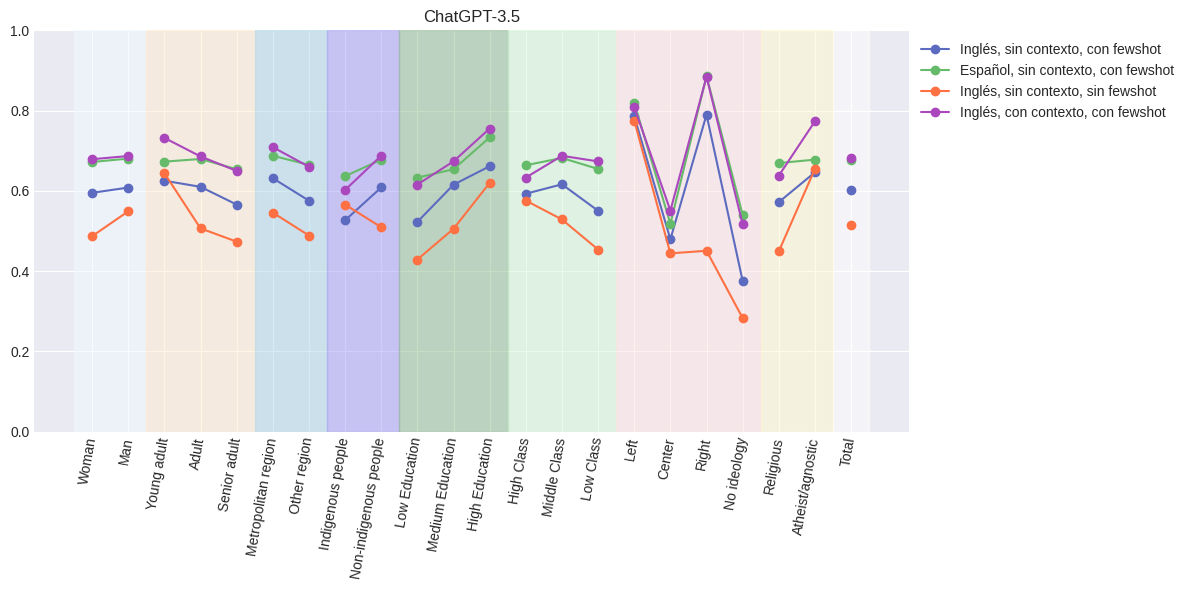

In [52]:
# Colores para cada modelo
modelos_colores = {
    "Inglés, sin contexto, con fewshot": "#5c6bc0",
    "Español, sin contexto, con fewshot": "#66bb6a",
    "Inglés, sin contexto, sin fewshot": "#ff7043",
    "Inglés, con contexto, con fewshot": "#ab47bc",
}

modelos = [gpt3_text_with_preamble_metrics, gpt3_esp_metrics, gpt_metrics_0, gpt3_context_metrics]
modelos_nombres = ["Inglés, sin contexto, con fewshot", "Español, sin contexto, con fewshot", "Inglés, sin contexto, sin fewshot", "Inglés, con contexto, con fewshot"]
sociodemographic_line_plot(modelos, modelos_colores, modelos_nombres, "ChatGPT-3.5")

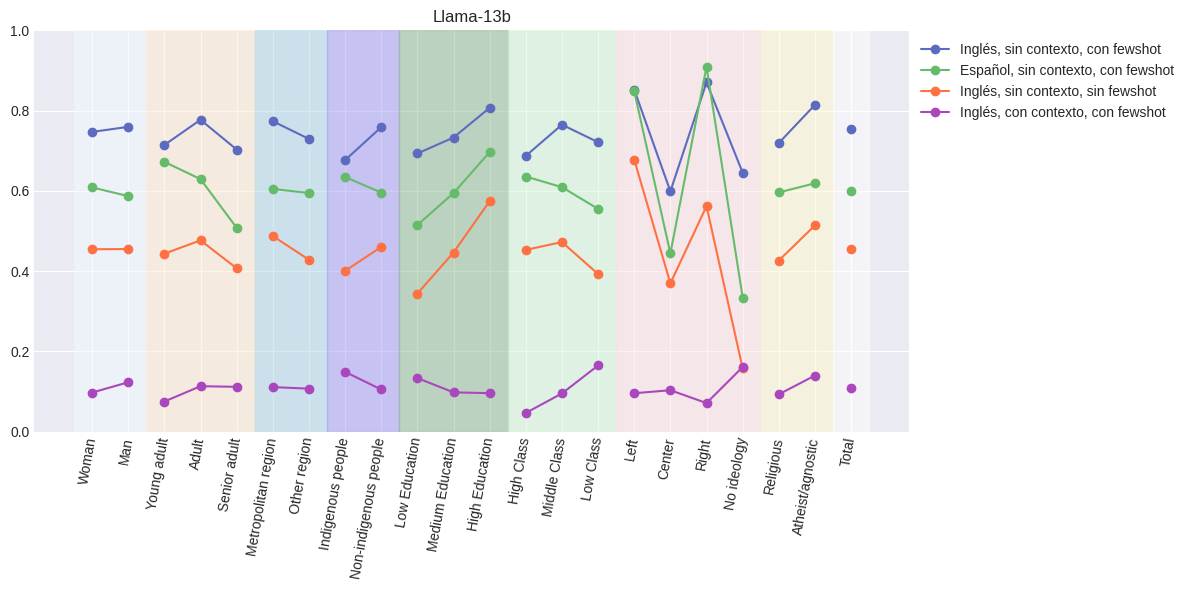

In [53]:
# Colores para cada modelo
modelos_colores = {
    "Inglés, sin contexto, con fewshot": "#5c6bc0",  # Azul suave
    "Español, sin contexto, con fewshot": "#66bb6a",               # Verde suave
    "Inglés, sin contexto, sin fewshot": "#ff7043", # Naranja suave
    "Inglés, con contexto, con fewshot": "#ab47bc",                 # Morado suave
}

modelos = [llama_text_with_preamble_metrics, llama_esp_metrics, llama_metrics_0, llama_context_metrics]
modelos_nombres = ["Inglés, sin contexto, con fewshot", "Español, sin contexto, con fewshot", "Inglés, sin contexto, sin fewshot", "Inglés, con contexto, con fewshot"]
sociodemographic_line_plot(modelos, modelos_colores, modelos_nombres, "Llama-13b")

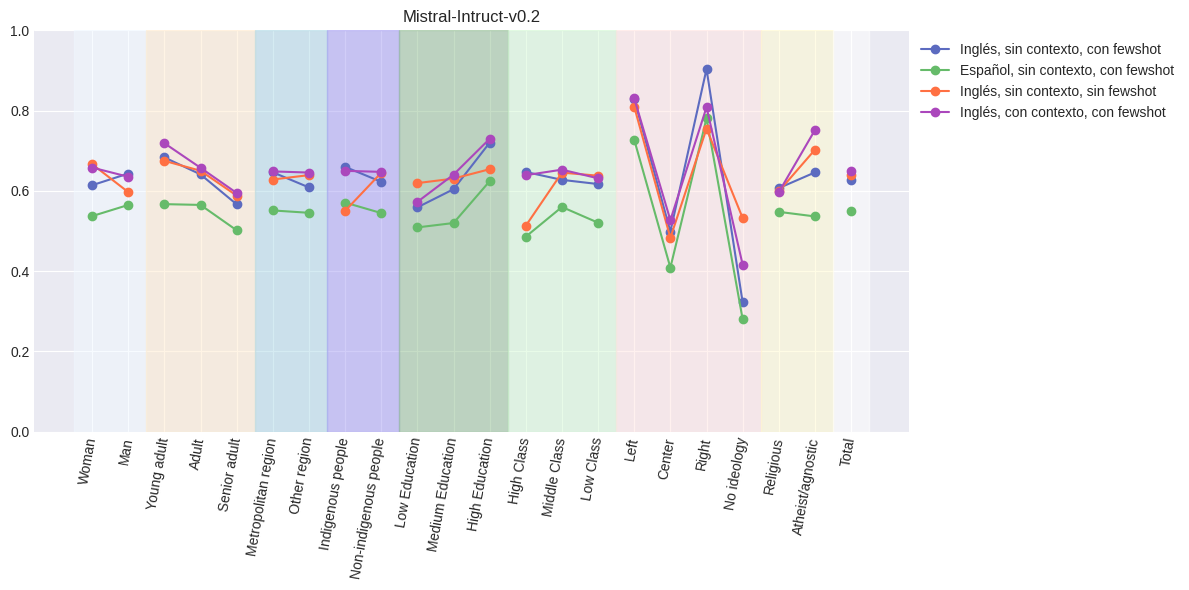

In [54]:
# Colores para cada modelo
modelos_colores = {
    "Inglés, sin contexto, con fewshot": "#5c6bc0",  # Azul suave
    "Español, sin contexto, con fewshot": "#66bb6a",               # Verde suave
    "Inglés, sin contexto, sin fewshot": "#ff7043", # Naranja suave
    "Inglés, con contexto, con fewshot": "#ab47bc",                 # Morado suave
}

modelos = [mistral_text_with_preamble_metrics, mistral_esp_metrics, mistral_metrics_0, mistral_context_metrics]
modelos_nombres = ["Inglés, sin contexto, con fewshot", "Español, sin contexto, con fewshot", "Inglés, sin contexto, sin fewshot", "Inglés, con contexto, con fewshot"]
sociodemographic_line_plot(modelos, modelos_colores, modelos_nombres, "Mistral-Intruct-v0.2")

# Bar PLots

## Prompt Designs Comparison


### Metrics Tables

In [ ]:
llama_table_p = metrics_by_prompt_table([llama_text_metrics, llama_list_metrics, llama_json_metrics, llama_text_with_preamble_metrics, llama_refpaper_metrics], "Llama-13b")
llama_table_p

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,Llama-13b,Text,0.578788,0.750519,0.653560
1,Llama-13b,List,0.583333,0.747286,0.655209
2,Llama-13b,Chain of thought,0.687879,0.897708,0.778909
3,Llama-13b,Text with Preamble,0.671212,0.931018,0.780051
4,Llama-13b,Completion,0.593939,0.719108,0.650558


In [ ]:
mistral_table_p = metrics_by_prompt_table([mistral_text_metrics, mistral_list_metrics, mistral_json_metrics, mistral_text_with_preamble_metrics, mistral_refpaper_metrics], "Mistral")
mistral_table_p

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,Mistral,Text,0.583333,0.756268,0.658638
1,Mistral,List,0.596970,0.746748,0.663511
2,Mistral,Chain of thought,0.537879,0.781805,0.637299
3,Mistral,Text with Preamble,0.575758,0.793547,0.667333
4,Mistral,Completion,0.518182,0.626690,0.567294


In [ ]:
t0_table_p = metrics_by_prompt_table([t0_text_metrics, t0_list_metrics, t0_json_metrics, t0_text_with_preamble_metrics, t0_refpaper_metrics], "T-zero", names_list=["Text-template", "List-Template", "Estructura JSON", "Diseñado por autores", "Prompt del paper"])
t0_table_p

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,T-zero,Text-template,0.240909,0.360170,0.288708
1,T-zero,List-Template,0.331818,0.381486,0.354923
2,T-zero,Estructura JSON,0.353030,0.336857,0.344754
3,T-zero,Diseñado por autores,0.396970,0.521589,0.450826
4,T-zero,Prompt del paper,0.236364,0.355950,0.284085


In [ ]:
chatgpt_table_p = metrics_by_prompt_table([gpt3_list_metrics, gpt3_text_metrics, gpt3_json_metrics, gpt3_text_with_preamble_metrics, gpt3_refpaper_metrics], "GPT3.5")
chatgpt_table_p

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,GPT3.5,Text,0.639394,0.931917,0.758427
1,GPT3.5,List,0.621212,0.870783,0.725124
2,GPT3.5,Chain of thought,0.640909,0.937673,0.761396
3,GPT3.5,Text with Preamble,0.557576,0.795129,0.655494
4,GPT3.5,Completion,0.610606,0.739772,0.669012


### Plots

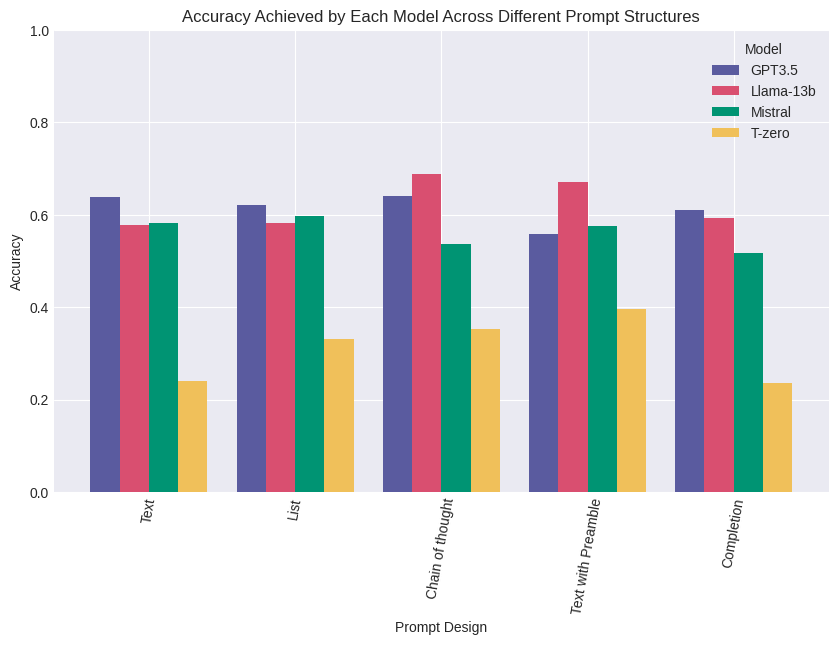

In [ ]:
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')
prompting_bar([chatgpt_table_p, llama_table_p, mistral_table_p, t0_table_p], "Accuracy Achieved by Each Model Across Different Prompt Structures",  "Prompt Design")

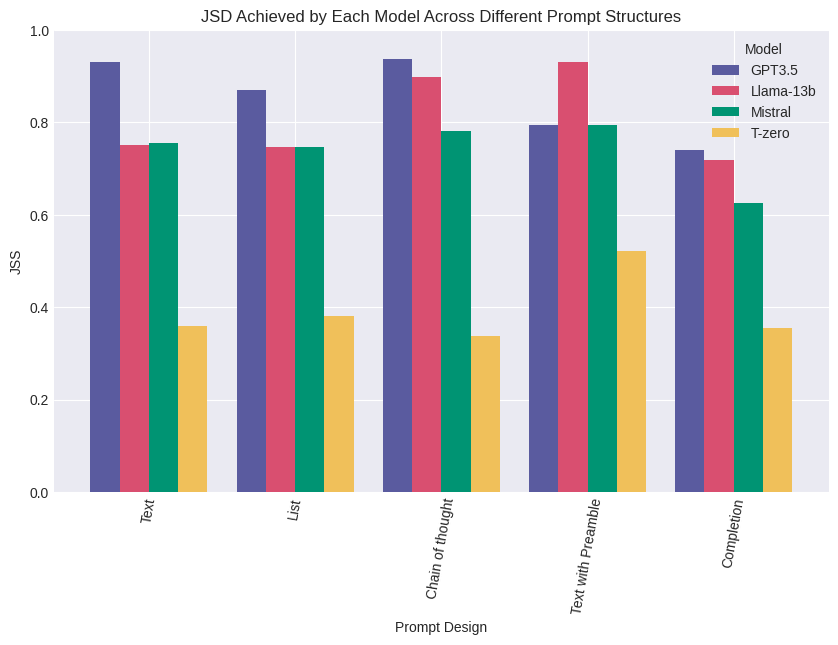

In [ ]:
prompting_bar([chatgpt_table_p, llama_table_p, mistral_table_p, t0_table_p ], "JSD Achieved by Each Model Across Different Prompt Structures", "Prompt Design", metric="JSS")

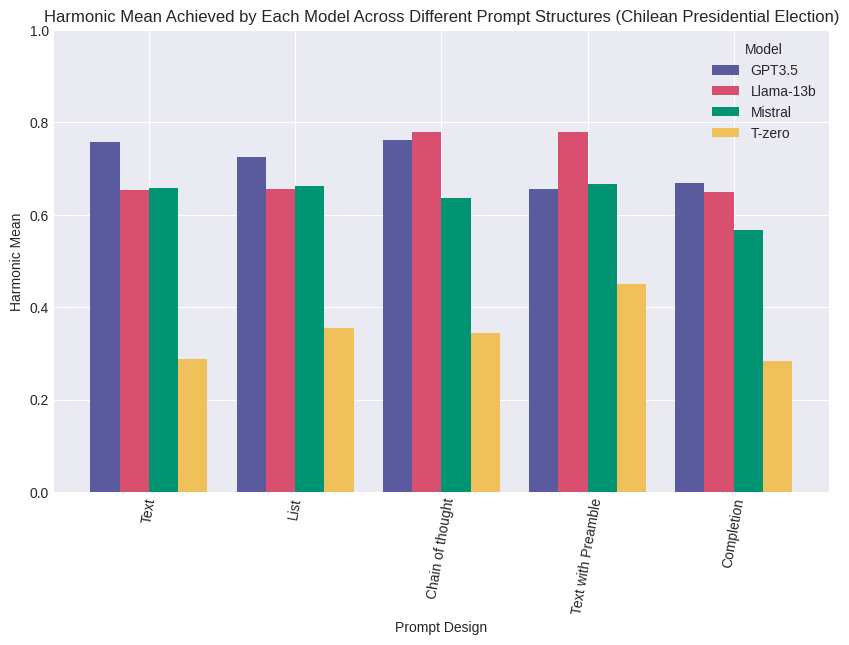

In [ ]:
prompting_bar([chatgpt_table_p, llama_table_p, mistral_table_p, t0_table_p], "Harmonic Mean Achieved by Each Model Across Different Prompt Structures (Chilean Presidential Election)", "Prompt Design", metric="Harmonic Mean")

## Context Prompts Comparison

### Matrics Tables

In [56]:
gpt_contexto_table = metrics_by_prompt_table([gpt3_context_metrics, gpt3_text_with_preamble_metrics], "GPT-3.5-turbo", names_list=["Con contexto", "Sin contexto"])
gpt_contexto_table

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,GPT-3.5-turbo,Con contexto,0.600000,0.791555,0.682593
1,GPT-3.5-turbo,Sin contexto,0.533333,0.689241,0.601346


In [57]:
llama_contexto_table = metrics_by_prompt_table([llama_context_metrics, llama_text_with_preamble_metrics], "Llama-13b", names_list=["Con contexto", "Sin contexto"])
llama_contexto_table

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,Llama-13b,Con contexto,0.077273,0.183981,0.108834
1,Llama-13b,Sin contexto,0.631818,0.933038,0.753437


In [58]:
mistral_contexto_table = metrics_by_prompt_table([mistral_context_metrics, mistral_text_with_preamble_metrics], "Mistral-v0.2", names_list=["Con contexto", "Sin contexto"])
mistral_contexto_table

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,Mistral-v0.2,Con contexto,0.562121,0.767059,0.648791
1,Mistral-v0.2,Sin contexto,0.534848,0.756312,0.626587


### Plots

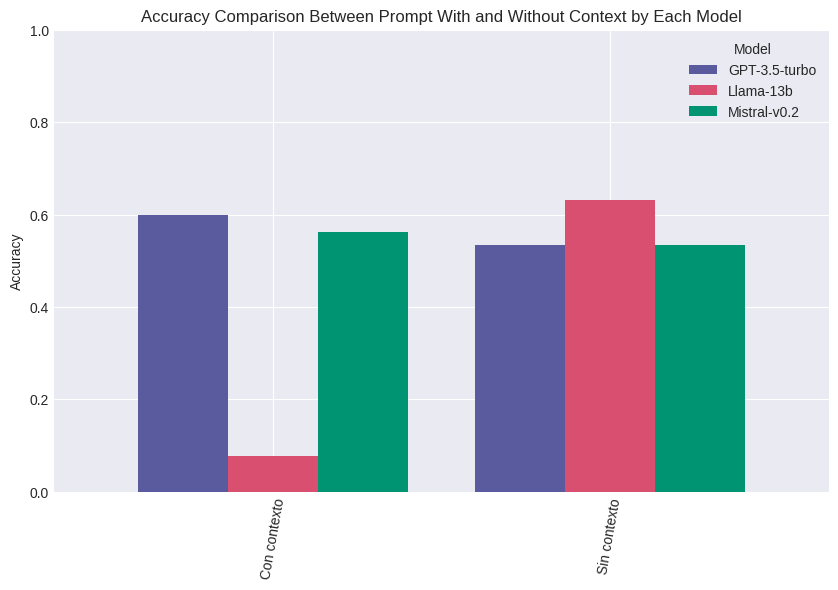

In [59]:
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')
prompting_bar([gpt_contexto_table, llama_contexto_table, mistral_contexto_table],"Accuracy Comparison Between Prompt With and Without Context by Each Model", "")

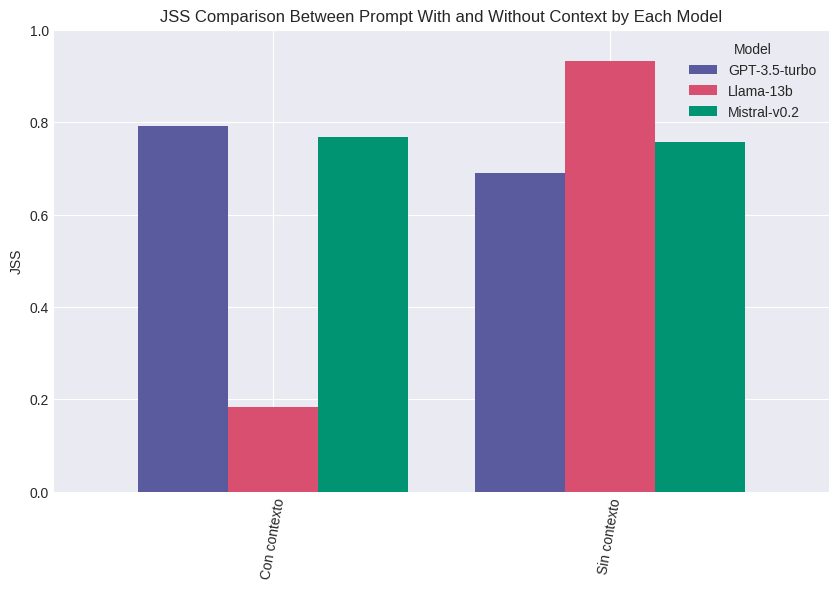

In [60]:
prompting_bar([gpt_contexto_table, llama_contexto_table, mistral_contexto_table],"JSS Comparison Between Prompt With and Without Context by Each Model","", metric="JSS")

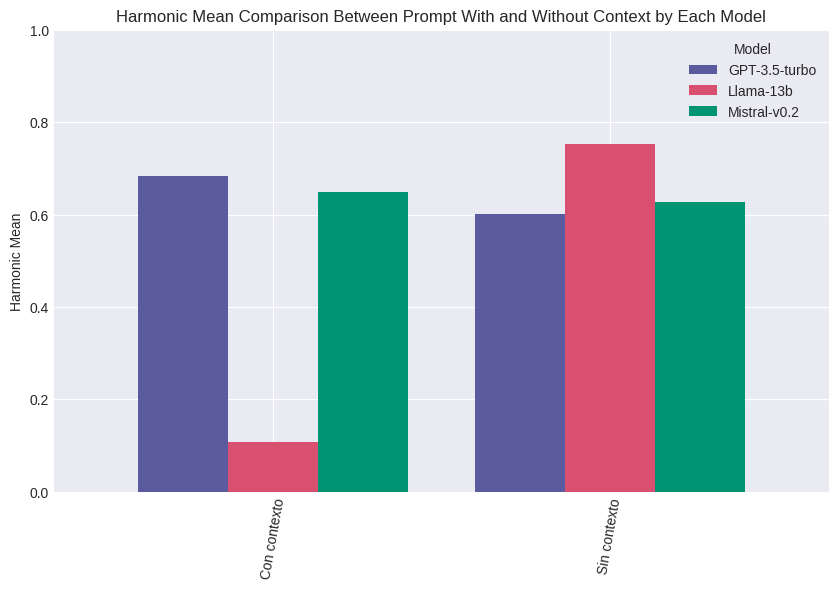

In [61]:
prompting_bar([gpt_contexto_table, llama_contexto_table, mistral_contexto_table],"Harmonic Mean Comparison Between Prompt With and Without Context by Each Model", "", metric="Harmonic Mean")

## Prompting Sin fewshot


### Metrics Tables

In [64]:
names_list=["English, without context, with fewshot", "Spanish, without context, with fewshot", "English, without context, without fewshot", "English, with context, with fewshot"]

In [65]:
gpt_0_table = metrics_by_prompt_table([gpt3_text_with_preamble_metrics, gpt3_esp_metrics, gpt_metrics_0, gpt3_context_metrics], "GPT-3.5-turbo", names_list = names_list)
gpt_0_table

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,GPT-3.5-turbo,"English, without context, with fewshot",0.533333,0.689241,0.601346
1,GPT-3.5-turbo,"Spanish, without context, with fewshot",0.587879,0.796578,0.676498
2,GPT-3.5-turbo,"English, without context, without fewshot",0.468182,0.572753,0.515215
3,GPT-3.5-turbo,"English, with context, with fewshot",0.600000,0.791555,0.682593


In [66]:
llama_0_table = metrics_by_prompt_table([llama_text_with_preamble_metrics, llama_esp_metrics, llama_metrics_0, llama_context_metrics], "Llama-13b", names_list=names_list)
llama_0_table

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,Llama-13b,"English, without context, with fewshot",0.631818,0.933038,0.753437
1,Llama-13b,"Spanish, without context, with fewshot",0.525758,0.700307,0.600608
2,Llama-13b,"English, without context, without fewshot",0.404545,0.520667,0.455319
3,Llama-13b,"English, with context, with fewshot",0.077273,0.183981,0.108834


In [68]:
mistral_0_table = metrics_by_prompt_table([mistral_text_with_preamble_metrics, mistral_esp_metrics, mistral_metrics_0, mistral_context_metrics], "Mistral", names_list=names_list)
mistral_0_table

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,Mistral,"English, without context, with fewshot",0.534848,0.756312,0.626587
1,Mistral,"Spanish, without context, with fewshot",0.465152,0.670534,0.549272
2,Mistral,"English, without context, without fewshot",0.554545,0.751794,0.638278
3,Mistral,"English, with context, with fewshot",0.562121,0.767059,0.648791


### Plots

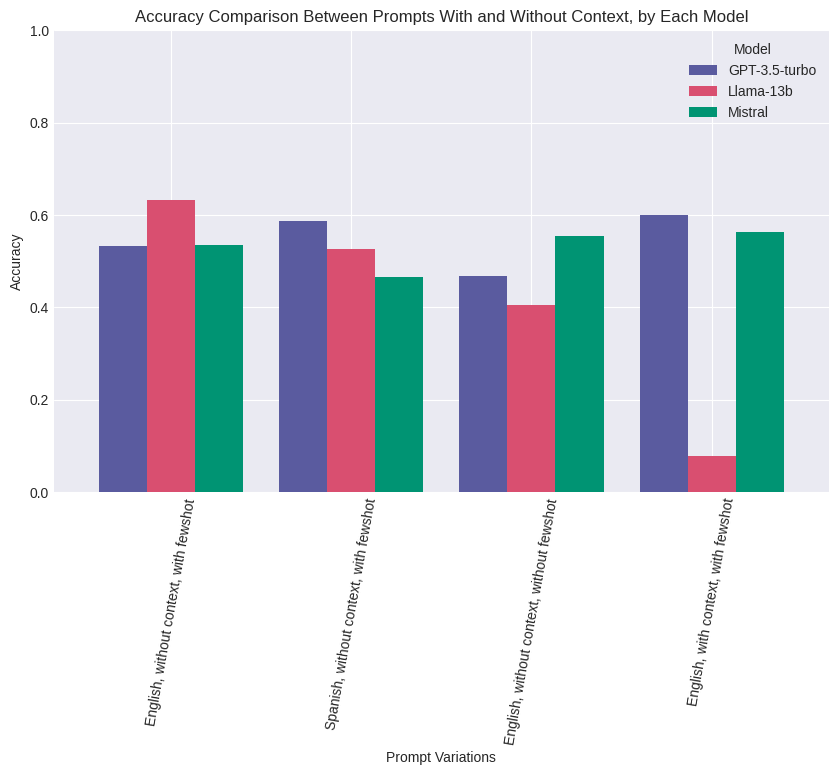

In [69]:
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')
prompting_bar([gpt_0_table, llama_0_table, mistral_0_table], "Accuracy Comparison Between Prompts With and Without Context, by Each Model", "Prompt Variations", metric = "Accuracy")

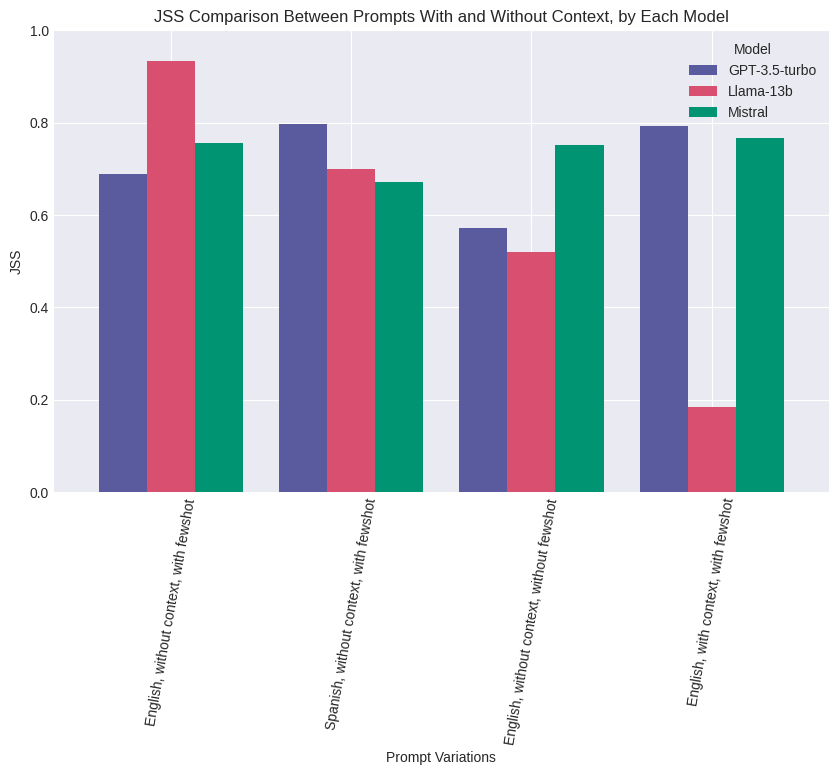

In [70]:
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')
prompting_bar([gpt_0_table, llama_0_table, mistral_0_table], "JSS Comparison Between Prompts With and Without Context, by Each Model", "Prompt Variations", metric = "JSS")

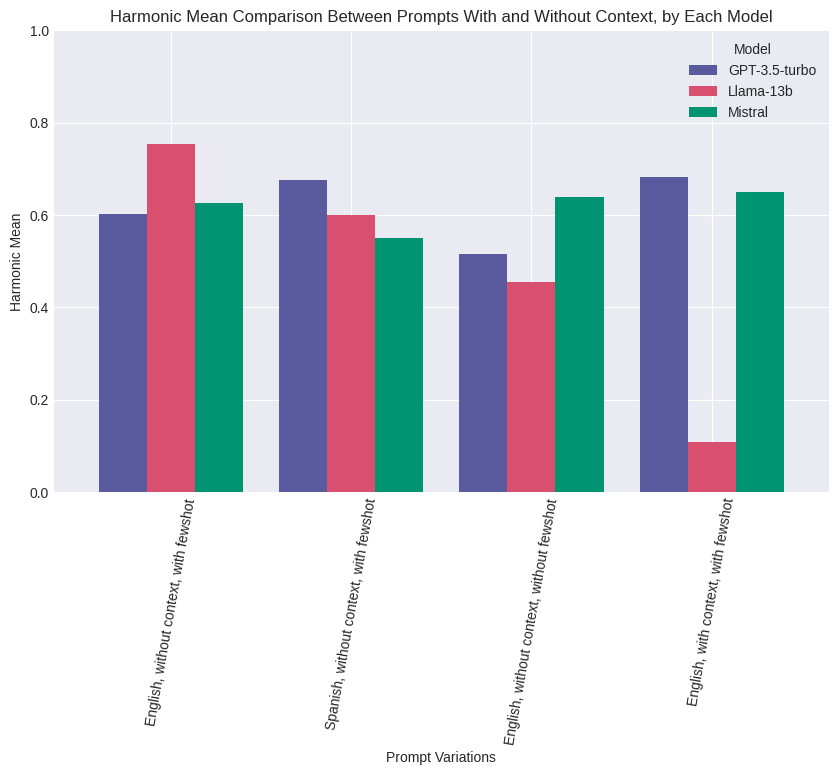

In [71]:
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')
prompting_bar([gpt_0_table, llama_0_table, mistral_0_table], "Harmonic Mean Comparison Between Prompts With and Without Context, by Each Model", "Prompt Variations", metric = "Harmonic Mean")

## Votes Distribution per Sociodemographic Group

In [72]:
df = pd.read_csv(results_route +"exp_inputs_filtrado.csv")

In [73]:
quantities_per_option_per_group(df, column_to_predict, ["Approve", "Reject", "Null"])

,Group,Approve,Reject,Null
0,Woman,177,195,13
1,Man,115,155,5
2,Young adult,47,27,4
3,Adult,178,203,6
4,Senior adult,67,120,8
5,Metropolitan region,132,153,3
6,Other region,160,197,15
7,Indigenous people,29,29,0
8,Non-indigenous people,261,319,18
9,Low Education,71,127,7


In [74]:
quantities_per_option_per_group(llama_json, "pred", ["Approve", "Reject", "Null"])

,Group,Approve,Reject,Null
0,Woman,197,174,14
1,Man,147,118,10
2,Young adult,56,20,2
3,Adult,213,164,10
4,Senior adult,75,108,12
5,Metropolitan region,165,114,9
6,Other region,179,178,15
7,Indigenous people,35,23,0
8,Non-indigenous people,308,266,24
9,Low Education,64,125,16


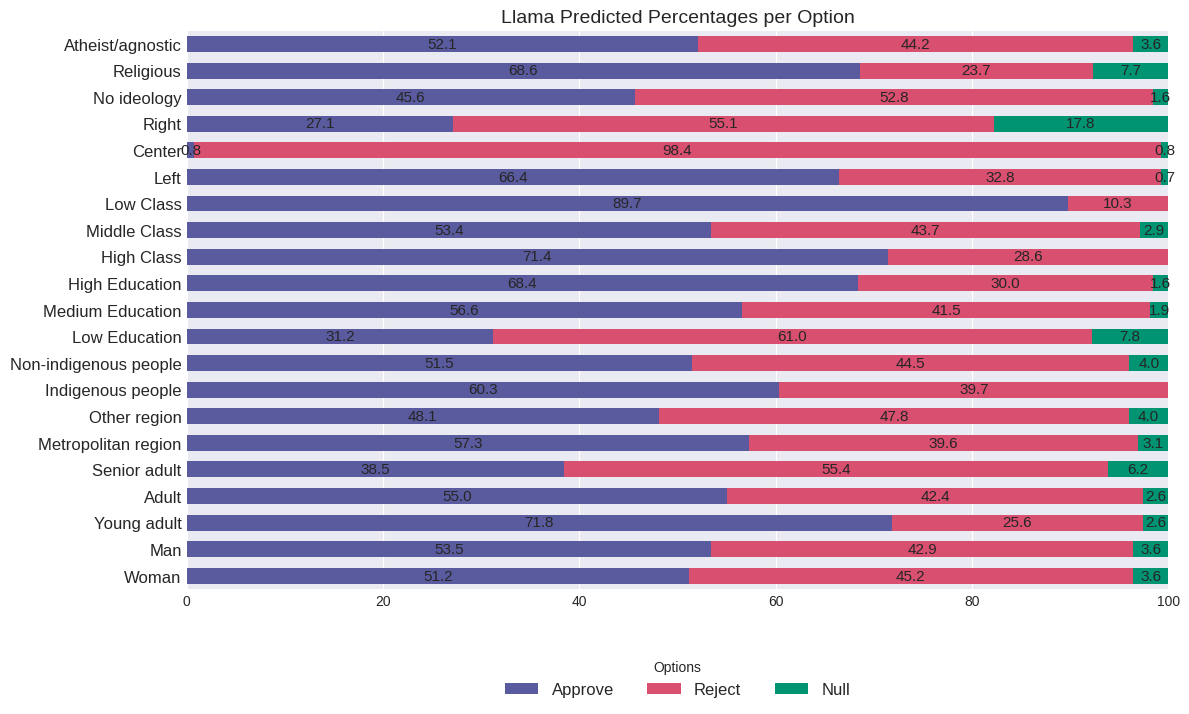

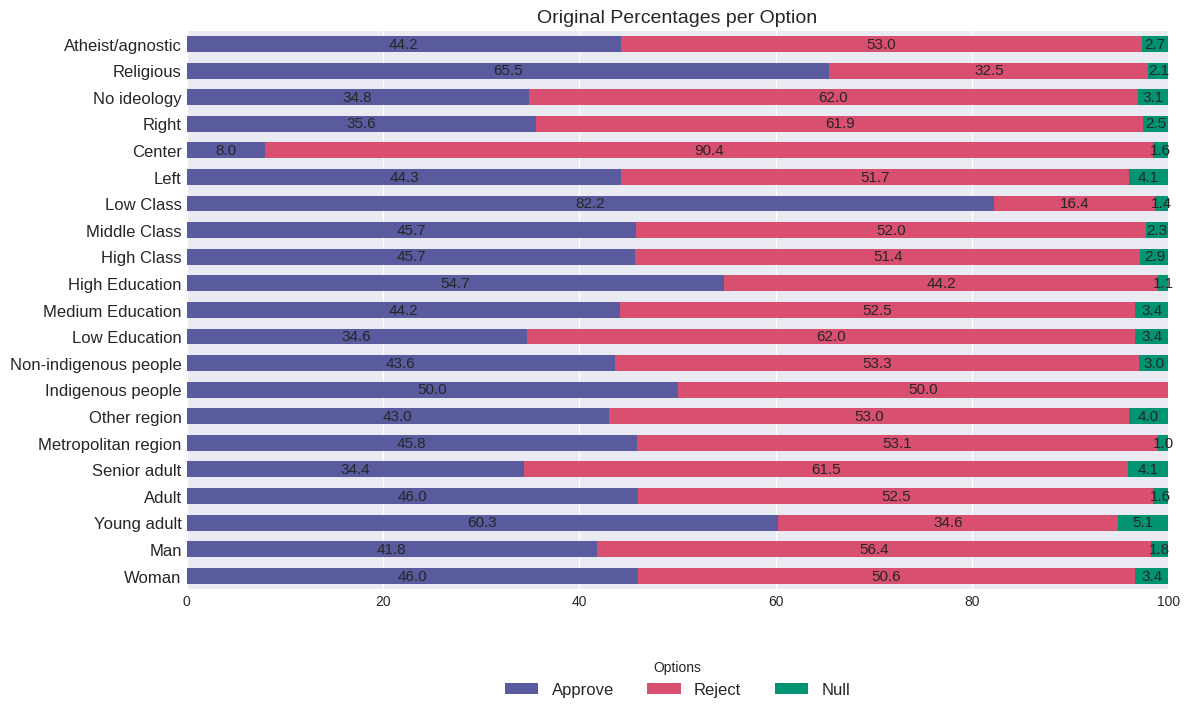

In [75]:
prop_llama = distribution_of_votes_per_group_graph(llama_json, "pred", ["Approve", "Reject", "Null"], 'Llama Predicted Percentages per Option')
prop_original = distribution_of_votes_per_group_graph(df, column_to_predict, ["Approve", "Reject", "Null"], 'Original Percentages per Option')



## Ablation Experiment
Results and graphs of ablation Experiment, using Llama-13b (the best model) and chain of thought prompt

In [76]:
llama_json_wpv = data_charger(results_route +"exp_inputs_filtrado.csv",  prompt_design_route +f"{experiment}_chile_llama_cot_without_political_vars.jsonl", d)
llama_json_onlypol = data_charger(results_route +"exp_inputs_filtrado.csv", prompt_design_route +f"{experiment}_chile_llama_cot_only_political_vars.jsonl", d)

In [77]:
df_llama13b_ablation = ablation_charger(results_route +"exp_inputs_filtrado.csv", prompt_design_route +f"{experiment}_chile_llama_cot_ablation.jsonl", d, remove=None)
df_llama13b_ablation

,Unnamed: 0.1,Unnamed: 0,Column1,sexo,edad,nom_region,zona_u_r,gse,esc_nivel_1,info_enc_58,...,pred_gender,pred_age,pred_region,pred_indigenous,pred_gse,pred_scholarity,pred_religion,pred_ideology,pred_party,pred_interest
0,0,0,3,2,40,METROPOLITANA,1,3,3,2,...,2,2,2,2,2,2,2,2,2,2
1,2,2,8,2,54,VALPARAÍSO,1,3,6,2,...,1,1,1,1,1,1,1,2,1,1
2,5,5,15,2,39,MAULE,1,2,8,2,...,2,2,2,2,2,2,2,2,2,2
3,6,6,17,1,21,MAULE,1,2,7,2,...,1,2,2,2,2,2,2,1,2,2
4,7,7,18,2,19,METROPOLITANA,1,2,4,2,...,2,2,2,2,2,2,2,1,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,808,808,1429,2,25,VALPARAÍSO,1,3,6,1,...,1,1,1,1,1,1,1,1,1,1
656,809,809,1434,2,25,METROPOLITANA,1,1,8,2,...,2,2,1,1,2,2,2,1,2,1
657,810,810,1436,2,22,METROPOLITANA,1,4,7,2,...,3,2,3,3,2,1,3,3,3,3
658,811,811,1439,1,54,ÑUBLE,1,1,8,2,...,1,1,1,1,1,1,1,2,1,1


In [78]:
df_llama13b_ablation.rename(columns={'pred_indigenous': 'pred_race'}, inplace=True)

In [79]:
df_list=[llama_json, llama_json_wpv, llama_json_onlypol]

Con llama13b se ve un comportamiento un poco más similar al de GPT, el rendimiento decae si no se incluyen las viariables políticas, o si solo se incluyen aquellas sin ninguna informacion sociodemográfica. Hay 2 variables: edad y escolaridad, que al quitarlas mejoran la precision pero nuevamente no logra superar el 5% por lo que no es un cambio considerable.

En este caso, no usar contexto hace empeorar la precisión en un 20%.

Nuevamente quitra la ideología genera una pérdida de precisión.

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/dri

,model,acc,jss,h
0,All,0.646970,0.924745,0.761311
1,Without political variables,0.527273,0.970823,0.683385
2,Only political variables,0.446970,0.793828,0.571918
3,- gender,0.640909,0.973984,0.773098
4,- age,0.589394,0.951084,0.727778
5,- region,0.595455,0.916752,0.721970
6,- race,0.592424,0.881252,0.708534
7,- gse,0.613636,0.894182,0.727810
8,- scholarity,0.615152,0.926709,0.739453
9,- religion,0.610606,0.872787,0.718527


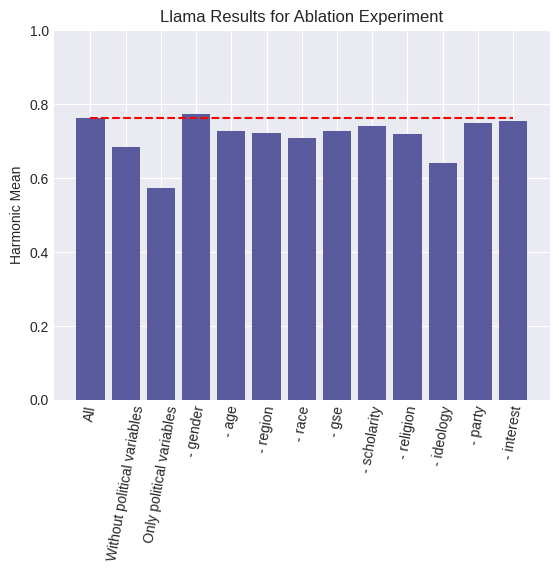

In [80]:
ablation_graph(df_list,df_llama13b_ablation, column_to_predict, 'Llama Results for Ablation Experiment', 'Harmonic Mean')